# Random Mutation of Test Inputs (SuT: `MnistCNN`)

In this exercise, we'll explore how **random mutations** of test inputs affect neuron coverage in a DNN. We'll apply simple image transformations (noise, brightness, rotation, dropout) and observe their impact on model accuracy and coverage metrics. 

In [1]:
import os, sys

# exercises → unit folder → modules → project_root
MODULES_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
CODE_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "code")
MODEL_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "model")
DATA_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "data")

if CODE_DIR not in sys.path:
    sys.path.append(CODE_DIR)

if MODEL_DIR not in sys.path:
    sys.path.append(MODEL_DIR)

if DATA_DIR not in sys.path:
    sys.path.append(DATA_DIR)

print("Added to sys.path:", CODE_DIR)
print("Added to sys.path:", MODEL_DIR)
print("Added to sys.path:", DATA_DIR)

Added to sys.path: /workspace/modules/exercise_artifacts/code
Added to sys.path: /workspace/modules/exercise_artifacts/model
Added to sys.path: /workspace/modules/exercise_artifacts/data


In [2]:
# Load pre-saved MNIST model
import torch
from mnist_model import load_trained_model
from torchinfo import summary

device = "cuda" if torch.cuda.is_available() else "cpu"

WEIGHTS_PATH = os.path.join(MODEL_DIR, "mnist_model_weights.pt")

model = load_trained_model(WEIGHTS_PATH, device=device)

print("MnistCNN Summary:")
summary(model, input_size=(1, 1, 28, 28), col_names=["input_size", "output_size", "num_params"])

MnistCNN Summary:


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
MnistCNN                                 [1, 1, 28, 28]            [1, 10]                   --
├─Conv2d: 1-1                            [1, 1, 28, 28]            [1, 8, 28, 28]            80
├─Conv2d: 1-2                            [1, 8, 14, 14]            [1, 16, 14, 14]           1,168
├─Linear: 1-3                            [1, 784]                  [1, 32]                   25,120
├─Linear: 1-4                            [1, 32]                   [1, 10]                   330
Total params: 26,698
Trainable params: 26,698
Non-trainable params: 0
Total mult-adds (M): 0.32
Input size (MB): 0.00
Forward/backward pass size (MB): 0.08
Params size (MB): 0.11
Estimated Total Size (MB): 0.19

In [3]:
# Load pre-saved MNIST subsets (using DATA_DIR defined above)
test_data = torch.load(os.path.join(DATA_DIR, "mnist_test_200.pt"))

test_images, test_labels = test_data["images"], test_data["labels"]

print(f"Test:  {test_images.shape}, {test_labels.shape}")

Test:  torch.Size([200, 1, 28, 28]), torch.Size([200])


In [4]:
from neuron_coverages import neuron_coverage, top_k_neuron_coverage
from mnist_instrumentation import forward_and_capture_relu

## Mutation Functions

We define four mutation functions to transform test inputs:

| Mutation | Description |
|----------|-------------|
| **Gaussian Noise** | Add random noise sampled from a normal distribution |
| **Brightness Shift** | Randomly increase or decrease pixel intensity |
| **Small Rotation** | Apply a small random rotation |
| **Pixel Dropout** | Randomly set pixels to zero |

In [11]:
import torchvision.transforms.functional as TF

def gaussian_noise(image, std=0.1):
    """Add Gaussian noise to the image."""
    noise = torch.randn_like(image) * std
    return torch.clamp(image + noise, 0, 1)

def brightness_shift(image, max_shift=0.2):
    """Randomly shift brightness."""
    shift = (torch.rand(1).item() - 0.5) * 2 * max_shift  # [-max_shift, max_shift]
    return torch.clamp(image + shift, 0, 1)

def small_rotation(image, max_angle=15):
    """Apply small random rotation."""
    angle = (torch.rand(1).item() - 0.5) * 2 * max_angle  # [-max_angle, max_angle]
    # TF.rotate expects [C, H, W] format
    return TF.rotate(image, angle)

def pixel_dropout(image, dropout_rate=0.05):
    """Randomly drop pixels (set to 0)."""
    mask = torch.rand_like(image) > dropout_rate  # True = keep, False = drop
    return image * mask

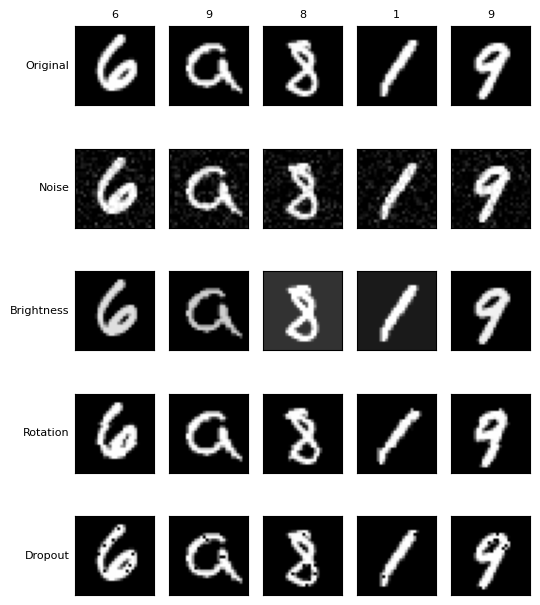

In [12]:
# Visualize the mutation functions (5 rows x 5 columns)
import matplotlib.pyplot as plt

# Select first 5 test images
n_images = 5
sample_images = test_images[:n_images]
sample_labels = test_labels[:n_images]

# Define mutations
mutations = [
    ("Original", lambda x: x),
    ("Noise", gaussian_noise),
    ("Brightness", brightness_shift),
    ("Rotation", small_rotation),
    ("Dropout", pixel_dropout),
]

# Create figure: rows = mutations, cols = images (compact size)
fig, axes = plt.subplots(len(mutations), n_images, figsize=(n_images * 1.1, len(mutations) * 1.3))

for row, (name, fn) in enumerate(mutations):
    for col in range(n_images):
        ax = axes[row, col]
        img = sample_images[col]
        mutated = fn(img)
        
        ax.imshow(mutated.squeeze(), cmap="gray", vmin=0, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])
        
        # Row label on first column
        if col == 0:
            ax.set_ylabel(name, fontsize=8, rotation=0, ha="right", va="center")
        # Column label (digit) on first row
        if row == 0:
            ax.set_title(f"{sample_labels[col].item()}", fontsize=8)

plt.tight_layout()
plt.show()


## Impact of test input mutation to the neuron coverages

In this section, we will explore how different test input mutations affect neuron coverage metrics in our trained MNIST CNN.
Applying mutations to test cases may help modify the test suite to achieve higher coverage.

Running mutation: Original ...
Running mutation: Noise ...
Running mutation: Brightness ...
Running mutation: Rotation ...
Running mutation: Dropout ...


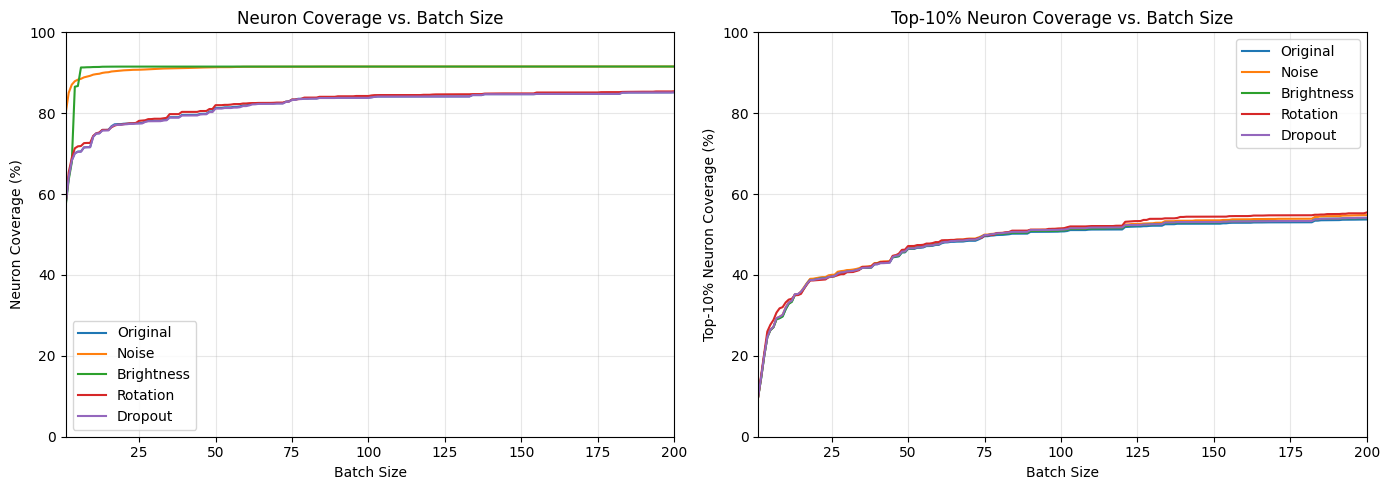

Accuracies:
  - Original: 93.0%
  - Noise: 89.5%
  - Brightness: 84.0%
  - Rotation: 85.0%
  - Dropout: 92.5%

Neuron Coverage (1 input → 200 inputs):
  - Original: 57.5% → 85.2%
  - Noise: 79.9% → 91.5%
  - Brightness: 57.0% → 91.5%
  - Rotation: 57.6% → 85.4%
  - Dropout: 57.5% → 85.2%

Top-10% Neuron Coverage (1 input → 200 inputs):
  - Original: 9.9% → 53.7%
  - Noise: 9.9% → 54.8%
  - Brightness: 9.9% → 54.0%
  - Rotation: 9.9% → 55.5%
  - Dropout: 9.9% → 54.1%


In [13]:
# Test neuron coverage across mutations and batch sizes
max_size = len(test_images)
batch_sizes = list(range(1, max_size + 1))

# Pre-apply all mutations to the entire test set (more efficient)
mutated_datasets = {}
with torch.no_grad():
    for name, mutation_fn in mutations:
        mutated_datasets[name] = torch.stack([mutation_fn(img) for img in test_images]).to(device)

# Store results per mutation: {name: {'nc': [...], 'topk': [...], 'acc': float}}
results = {}

with torch.no_grad():
    for name, mutation_fn in mutations:
        print(f"Running mutation: {name} ...")
        neuron_covs = []
        topk_covs = []
        mutated_images = mutated_datasets[name]
        
        for size in batch_sizes:
            # Use pre-mutated images
            inputs = mutated_images[:size]
            outputs, activations = forward_and_capture_relu(model, inputs)
            
            # Calculate accuracy at max size
            if size == max_size:
                preds = outputs.argmax(dim=1)
                acc = (preds == test_labels.to(device)).float().mean().item()
            
            # Calculate coverages
            nc, _ = neuron_coverage(activations)
            tk, _ = top_k_neuron_coverage(activations, k=0.1)
            neuron_covs.append(nc)
            topk_covs.append(tk)
        
        results[name] = {'nc': neuron_covs, 'topk': topk_covs, 'acc': acc}

# Plot neuron coverage comparison
colors = plt.cm.tab10.colors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Neuron Coverage
ax1 = axes[0]
for i, (name, data) in enumerate(results.items()):
    ax1.plot(batch_sizes, [c * 100 for c in data['nc']], 
             color=colors[i], linewidth=1.5, label=name)
ax1.set_xlabel("Batch Size")
ax1.set_ylabel("Neuron Coverage (%)")
ax1.set_title("Neuron Coverage vs. Batch Size")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(1, max_size)
ax1.set_ylim(0, 100)

# Right: Top-k Neuron Coverage
ax2 = axes[1]
for i, (name, data) in enumerate(results.items()):
    ax2.plot(batch_sizes, [c * 100 for c in data['topk']], 
             color=colors[i], linewidth=1.5, label=name)
ax2.set_xlabel("Batch Size")
ax2.set_ylabel("Top-10% Neuron Coverage (%)")
ax2.set_title("Top-10% Neuron Coverage vs. Batch Size")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(1, max_size)
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()

# Print summary
print("Accuracies:")
for name, data in results.items():
    print(f"  - {name}: {data['acc']:.1%}")

print(f"\nNeuron Coverage (1 input → {max_size} inputs):")
for name, data in results.items():
    print(f"  - {name}: {data['nc'][0]:.1%} → {data['nc'][-1]:.1%}")

print(f"\nTop-10% Neuron Coverage (1 input → {max_size} inputs):")
for name, data in results.items():
    print(f"  - {name}: {data['topk'][0]:.1%} → {data['topk'][-1]:.1%}")
